# Assignment 2

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Linear Regression

Let's set up our workspace and use the **Auto MPG dataset**. This dataset contains several features (such as horsepower, weight, displacement, and acceleration) and a target variable indicating the car's **miles per gallon (MPG)**.

Here, we will model **MPG (continuous outcome)** based on the car's physical and performance characteristics.

In [1]:
# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
import seaborn as sns

# Load the Auto MPG dataset
mpg_data = sns.load_dataset('mpg')

# Drop rows with missing values
mpg_data = mpg_data.dropna(subset=['mpg', 'horsepower', 'weight', 'displacement'])

# Display the DataFrame
mpg_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


#### **Question 1:**  
#### Data inspection

Before fitting any model, it is essential to understand our data. **Use Python code** to answer the following questions about the **Auto MPG dataset**:

_(i)_ How many observations (rows) does the dataset contain and also how many variables (columns) does the dataset contain?

In [3]:
# the below output suggests that the MPG dataset has 392 rows and 9 total columns. 
# Seems that several rows were dropped in the dataset in the module in my package
mpg_data

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


_(ii)_ What is the 'variable type' of the response variable `mpg` (e.g., 'integer', 'category', etc.) and explain what it is in short? (1-2 sentences at max)

In [ ]:
# mpg variable is a float (float64): in this case with 64-bit precision
# this means that there can be about 16 digits in one number, including digits after comma
mpg_data["mpg"].dtype

dtype('float64')

Your explanation... 


_(iii)_ Find the 5 rows with the greatest `horsepower`.

In [ ]:
# used .nlargest method according to research (which suggested that:
# This method is equivalent to df.sort_values(columns, ascending=False).head(n), but more performant).
mpg_data.nlargest(5, "horsepower")


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
116,16.0,8,400.0,230.0,4278,9.5,73,usa,pontiac grand prix
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
13,14.0,8,455.0,225.0,3086,10.0,70,usa,buick estate wagon (sw)
95,12.0,8,455.0,225.0,4951,11.0,73,usa,buick electra 225 custom
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala


_(iv)_ How many predictor variables do we have (Hint: all variables other than `mpg`)?

In [19]:
# verify origin countries to inspect data further
mpg_data['origin'].value_counts()

origin
usa       245
japan      79
europe     68
Name: count, dtype: int64

In [25]:
# 6 predictor variable columns as string "origin" won't do anything for linear regression. 
# Dropped the 3 columns (mpg, originand name) in the code below
# as much as some people want their car to perform better based on its name or color (red go fasta!), 
# ...I'd drop the name as a predictor variable. 
# dropping them won't affect the original dataframe
print(mpg_data.drop(columns=["mpg", "name", "origin"]).shape[1],"predictor variables")


6 predictor variables


You can use `print()` and `describe()` to help answer these questions.

#### **Question 2:** 
#### Data-visualization

Before we fit and review model outputs, we should visualize our data. Review the code and plot, shown below.

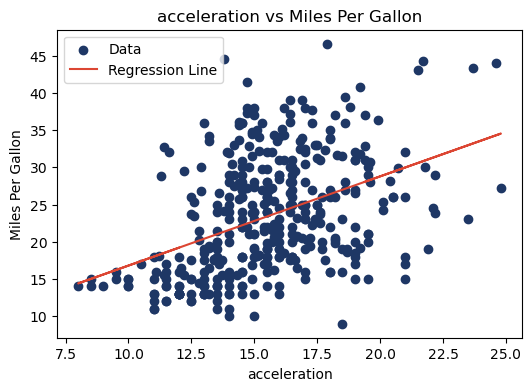

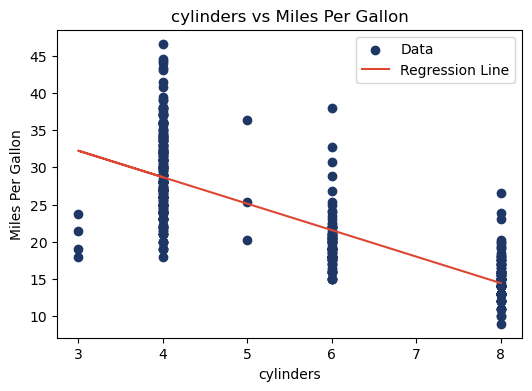

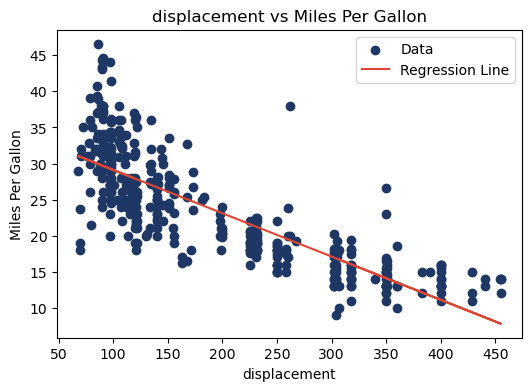

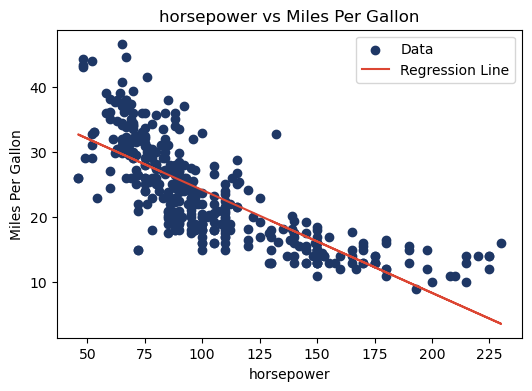

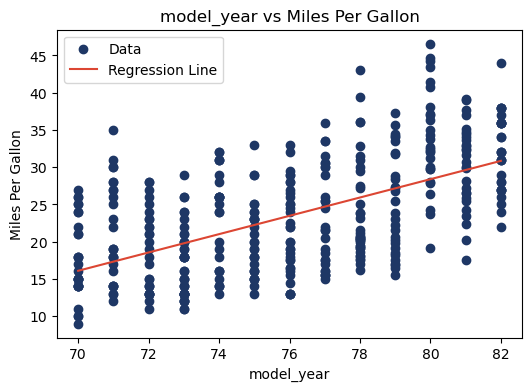

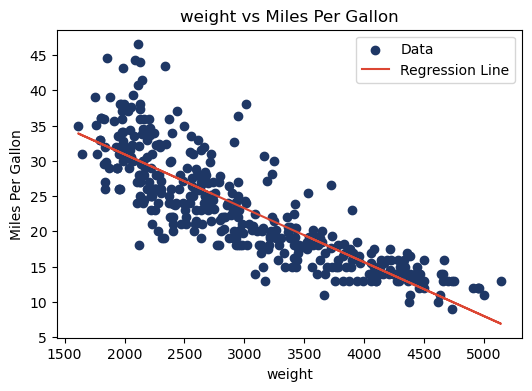

In [18]:
# Exclude the 'mpg' (target variable) and non-numeric columns from the feature names
feature_names = mpg_data.select_dtypes(include=[float, int]).columns.difference(['mpg'])

# Loop through each numeric feature (column) in mpg_data
for feature in feature_names:
    # Extract the feature column and target variable (mpg)
    X_feature = mpg_data[[feature]].values  # Extract as a 2D array
    y = mpg_data['mpg'].values  # Target variable (mpg)
    
    # Create a scatter plot for the feature against the target (mpg)
    plt.figure(figsize=(6, 4))
    plt.scatter(X_feature, y, label='Data', color='#1E3765')

    # Fit a linear regression model
    lm = LinearRegression()
    lm.fit(X_feature, y)

    # Plot the regression line
    plt.plot(X_feature, lm.predict(X_feature), color='#DC4633', label='Regression Line')

    # Add labels and title
    plt.xlabel(feature)
    plt.ylabel('Miles Per Gallon')
    plt.title(f'{feature} vs Miles Per Gallon')

    # Add a legend
    plt.legend()

    # Show the plot
    plt.show()

Answer the following questions:

_(i)_ Describe the associations being plotted ? (i.e., positive association, negative association, no association)

*Note: I changed the plot colors to the ones from the [official UofT branding guidelines](https://archive.brand.utoronto.ca/guidelines/); this is just my minor graphic design background talking in me, I have no control over it ._.*

**Answer:**

**Acceleration:** suggests weak or no association, but the regression line hints at a positive association (more sec → more MPG, faster → less economical)

**Cylinders:** negative association. The more cylinders, the lower the MPG (gas economy) is.

**Displacement:** also negative association. The more centilitres (400 likely represents 4 litres of air displacement), the worse the gas economy is (lower MPG).

**Horsepower:** also negative association. More horsepower means lower MPG.

**Model year:** positive association. Later model year means higher MPG.

**Weight:** negative association. More weight means lower MPG.


_(ii)_ What concept ‘defines’ the plotted line?

The plotted line represents the line of best fit. It's defined by linear regression.

_(iii)_ Do all data points in the dataset fall perfectly along the plotted line? If not, why might there be deviations between the data points and the line, and what do these deviations indicate about the relationship between the variables?

They don't fall perfectly along the plotted line. How scattered the data points are related to the line shows the strength of the association. The more scattered they are, the weaker the association is.
Horsepower is also an example of a drop-off in horsepower affecting MPG. After 100-150 hp, the loss in efficiency (MPG) starts falling off (KNN regression might be able to show it better).
The accuracy is assessed using RMSPE - Root Mean Squared Prediction Error

#### **Question 3:**  
#### Model fit  
Now, let’s fit a multivariable linear regression model using the general syntax `lm()`. As above, use **mpg** as the response variable **Y**, and all other variables as the predictors.

**Step 1: Split the dataset into train and test sets, using a 75-25 split. (use random_state=42)**

In [26]:
mpg_train, mpg_test = train_test_split(mpg_data, test_size=0.25, random_state=42)

**Step 2: Fit the linear regression model.**

In [ ]:
# Tried to drop the non-numeric columns directly in the code below but got an error via data/train
# Tried to scale the variables despite linear regression but got stuck
# wanted to use StandardScaler or smth to see relative effect of each predictor on mpg

# numeric_predictors = mpg_data.train(columns=["mpg", "name", "origin"]).columns

numeric_predictors = mpg_train[["cylinders","displacement","horsepower","weight","acceleration","model_year"]]

X_train = numeric_predictors
y_train = mpg_train["mpg"]

lm = LinearRegression()
lm.fit(X_train, y_train)

# Create a DataFrame containing the slope (coefficients) and intercept
coefficients_df = pd.DataFrame({
    "predictor": numeric_predictors.columns,
    "slope": lm.coef_,
    "intercept": [lm.intercept_] * len(lm.coef_)
})

# Display the coefficients DataFrame
print(coefficients_df)

# lm.coef_ gives the coefficients for each predictor (change in miles per gallon per unit change in each predictor variable)
# lm.intercept_ gives the intercept b_0 (the predicted miles per gallon when all predictors are set to 0)

      predictor     slope  intercept
0     cylinders -0.160143 -15.047371
1  displacement  0.000373 -15.047371
2    horsepower -0.001899 -15.047371
3        weight -0.006457 -15.047371
4  acceleration  0.057588 -15.047371
5    model_year  0.762270 -15.047371


#### **Question 4:** 
#### RMSPE
**Step 3. Finally, we predict on the test data set to assess how well our model does.** 

We will evaluate our final model's test error measured by RMSPE.

In [36]:
# Finally, we predict on the test data set to assess how well our model does.** We will evaluate our final model's test error measured by RMSPE.
mpg_test["mpg_predicted"] = lm.predict(
    mpg_test[["cylinders","displacement","horsepower","weight","acceleration","model_year"]])

rmspe = mean_squared_error(
    y_true=mpg_test["mpg"],
    y_pred=mpg_test["mpg_predicted"]
)**0.5
rmspe

3.185474951339159

the above means that our predictions are off by 3.2 MPG

In [ ]:
# below is VIF (Variance Inflation Factor) to check for multicollinearity
# This is in addition to Question 4 answer
# this is because horsepower, displacement and cylinders are definitely correlated

!pip install statsmodels

In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# not sure if I can use 3 predictors instead of 2 or all, but I'll try anyway. Will ask in class
X = mpg_data[["cylinders","displacement","horsepower"]]
vif_data = pd.DataFrame()
vif_data["spec"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,spec,VIF
0,cylinders,35.639581
1,displacement,23.366071
2,horsepower,33.677856


VIF score is way over 5, meaning those 3 specifications (features) are strongly correlated.

# Criteria

| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is inspected for the number of variables, observations, and data types. | Data inspection is missing or incomplete.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots, histograms) are properly interepreted to explore the relationships between variables. | Data visualization were not correctly interpreted. |
| **Model Initialization**                               | The linear regression model is correctly initialized.            | The linear regression model is not initialized or is incorrect. |
| **Model Evaluation on Test Data**                      | The model is evaluated on the test data using appropriate metrics (e.g., RMSE). | The model evaluation is missing or uses the wrong metric. |


## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 09/14/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
